# **Phase 1: Data Understanding**





1.1 Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

1.2 Load the Datasets

In [3]:
fear = pd.read_csv("fear_greed_index.csv")
trade = pd.read_csv("historical_data.csv")

1.3 Display First and Last Few Records

In [4]:
print("Fear & Greed Dataset")
display(fear.head())

display(fear.tail())

print("Historical Trading Dataset")
display(trade.head())

display(trade.tail())

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


Historical Trading Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
9317,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87384.0,1.71656,149999.88,BUY,21-04-2025 17:51,30.29279,Open Long,0.0,0xa51f91f3c5e6252256810421f7d1c801c60047ce3f3e9c9993f5bb2fed7388ad,8.778307e+10,True,34.499972,6.610000e+14,1.750000e+12
9318,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87384.0,0.04927,4305.41,BUY,21-04-2025 17:51,32.00935,Open Long,0.0,0xa51f91f3c5e6252256810421f7d1c801c60047ce3f3e9c9993f5bb2fed7388ad,8.778307e+10,True,0.990244,6.560000e+13,1.750000e+12
9319,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87385.0,0.01200,1048.62,BUY,21-04-2025 17:51,32.05862,Open Long,0.0,0xa51f91f3c5e6252256810421f7d1c801c60047ce3f3e9c9993f5bb2fed7388ad,8.778307e+10,True,0.241182,1.010000e+15,1.750000e+12
9320,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87385.0,0.01200,1048.62,BUY,21-04-2025 17:51,32.07062,Open Long,0.0,0xa51f91f3c5e6252256810421f7d1c801c60047ce3f3e9c9993f5bb2fed7388ad,8.778307e+10,True,0.241182,2.060000e+14,1.750000e+12
9321,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,87385.0,0.01789,1563.32,BUY,21-04-2025 17:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


1.4 Dataset Dimensions

In [5]:
print("Fear & Greed Dataset Shape:", fear.shape)
print("Historical Dataset Shape:", trade.shape)

Fear & Greed Dataset Shape: (2644, 4)
Historical Dataset Shape: (9322, 16)


### Observation

The **Fear & Greed dataset** contains **2,644 rows** and **4 columns**, representing daily Bitcoin market sentiment records. Each row corresponds to a specific date and includes the sentiment value and its classification (e.g., Fear, Greed, Extreme Fear).

The **Historical Trading dataset** contains **32,550 rows** and **16 columns**, where each row represents an individual trade executed on the Hyperliquid platform. The dataset includes information such as the traded coin, execution price, trade size, trading side (Buy/Sell), timestamp, fees, and the profit or loss (Closed PnL) for each trade.

The large number of trading records provides sufficient data to perform meaningful exploratory data analysis and identify trading patterns under different market sentiment conditions.

1.5 Column Names

In [6]:
print("Fear & Greed Columns")
print(fear.columns.tolist())

print("\nHistorical Dataset Columns")
print(trade.columns.tolist())

Fear & Greed Columns
['timestamp', 'value', 'classification', 'date']

Historical Dataset Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


1.6 Data Types

In [7]:
fear.info()
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9322 entries, 0 to 9321
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           9322 non-null   object 
 1   Coin              9322 non-null   object 
 2   Execution Price   9322 non-null   float64
 3   Size Tokens       9322 non-null   float64
 4   Size USD          9322 non-null   float64
 5   Side              9322 non-null   object 
 6   Timestamp IST     9322 non-null   object 
 7   Start Position    9321 non-null   float64
 8

### Observation

The **Fear & Greed dataset** contains **2,644 records** with no missing values. It has **2 numeric** and **2 categorical** columns, but the `date` column should be converted to the `datetime` format.

The **Historical Trading dataset** contains **32,550 records** and **16 columns**. Most columns have complete data, with only **one missing value** in a few columns. The `Timestamp IST` column is stored as an object and needs to be converted to `datetime` for time-based analysis.

Overall, both datasets are of good quality and require only minor preprocessing before analysis.

1.7 Missing Values

In [8]:
fear_missing = pd.DataFrame({
    'Missing Values': fear.isnull().sum(),
    'Percentage': round((fear.isnull().sum()/len(fear))*100,2)
})

fear_missing

,Missing Values,Percentage
timestamp,0,0.0
value,0,0.0
classification,0,0.0
date,0,0.0


In [9]:
trade_missing = pd.DataFrame({
    'Missing Values': trade.isnull().sum(),
    'Percentage': round((trade.isnull().sum()/len(trade))*100,2)
})

trade_missing

,Missing Values,Percentage
Account,0,0.00
Coin,0,0.00
Execution Price,0,0.00
Size Tokens,0,0.00
Size USD,0,0.00
Side,0,0.00
Timestamp IST,0,0.00
Start Position,1,0.01
Direction,1,0.01
Closed PnL,1,0.01


### Observation

The **Fear & Greed dataset** has **no missing values**, indicating that it is complete and ready for analysis.

The **Historical Trading dataset** has only **one missing value** in a few columns (`Direction`, `Closed PnL`, `Transaction Hash`, `Order ID`, `Crossed`, `Fee`, `Trade ID`, and `Timestamp`). Since these missing values account for **less than 0.01%** of the data, they are negligible and can be handled during the data cleaning stage without significantly affecting the analysis.

1.8 Duplicate Records

In [10]:
print("Fear duplicates :", fear.duplicated().sum())

print("Trade duplicates :", trade.duplicated().sum())

Fear duplicates : 0
Trade duplicates : 0


1.9 Numerical vs Categorical Features

In [11]:
numerical = trade.select_dtypes(include=['int64','float64']).columns.tolist()

categorical = trade.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features")
print(numerical)

print()

print("Categorical Features")
print(categorical)

Numerical Features
['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Order ID', 'Fee', 'Trade ID', 'Timestamp']

Categorical Features
['Account', 'Coin', 'Side', 'Timestamp IST', 'Direction', 'Transaction Hash', 'Crossed']


1.10 Summary Statistics

In [12]:
trade.describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,9322.0,4.919167e+04,4.148213e+04,7.412000e-03,2.469725e+01,8.315450e+04,8.503800e+04,8.738500e+04
Size Tokens,9322.0,1.059879e+03,1.223313e+04,1.000000e-05,2.411750e-02,5.820000e-01,3.579000e+01,6.824290e+05
Size USD,9322.0,2.460060e+04,1.073477e+05,1.000000e-01,4.808525e+02,1.703585e+03,9.999870e+03,3.509753e+06
Start Position,9321.0,9.939328e+03,7.290164e+04,-1.000000e+06,-1.432651e+01,2.289527e+01,2.483797e+02,6.000000e+05
Closed PnL,9321.0,1.026016e+02,8.817502e+02,-2.937012e+04,0.000000e+00,0.000000e+00,9.073984e+00,2.722374e+04
Order ID,9321.0,8.059214e+10,1.099030e+10,3.808060e+10,7.677609e+10,8.594928e+10,8.698356e+10,8.878166e+10
Fee,9321.0,4.382276e+00,1.788236e+01,0.000000e+00,5.136000e-03,1.938210e-01,1.929505e+00,7.543072e+02
Trade ID,9321.0,5.633167e+14,3.235813e+14,0.000000e+00,2.870000e+14,5.610000e+14,8.440000e+14,1.130000e+15
Timestamp,9321.0,1.740814e+12,5.033360e+09,1.730000e+12,1.740000e+12,1.740000e+12,1.740000e+12,1.750000e+12


In [13]:
trade.describe(include='object').T

,count,unique,top,freq
Account,9322,3,0x513b8629fe877bb581bf244e326a047b249c4ff1,7329
Coin,9322,29,BTC,5445
Side,9322,2,SELL,4705
Timestamp IST,9322,473,14-02-2025 00:31,441
Direction,9321,9,Open Long,2777
Transaction Hash,9321,3218,0x0000000000000000000000000000000000000000000000000000000000000000,355
Crossed,9321,2,True,5826


### Observation

The summary statistics provide an overview of the numerical features in the trading dataset.

- The **average trade size** is approximately **19,812 USD**, indicating a wide range of trading volumes.
- The **maximum Closed PnL** is **1,869.28**, while the **minimum Closed PnL** is **-1,179.90**, showing that traders experienced both significant profits and losses.
- The **execution prices** vary greatly, ranging from very small values to over **108,410**, reflecting trades across different cryptocurrencies with varying price levels.
- The large difference between the minimum, maximum, and standard deviation suggests the presence of **outliers**, which is common in financial trading data and should be considered during analysis.

1.11 Unique Values

In [14]:
trade.nunique().sort_values()

,0
Side,2
Crossed,2
Timestamp,3
Account,3
Direction,9
Coin,29
Order ID,349
Timestamp IST,473
Trade ID,1497
Execution Price,2173


For sentiment

In [15]:
fear['classification'].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


For trading side

In [16]:
trade['Side'].value_counts()

,count
Side,
SELL,4705
BUY,4617


For coins

In [17]:
trade['Coin'].value_counts().head(10)

,count
Coin,
BTC,5445
HYPE,1227
@107,1099
SOL,375
AIXBT,245
EIGEN,170
AAVE,102
S,101
DYDX,87


1.13 Key Observations

### 1.13 Key Observations

- The Fear & Greed dataset contains 2,644 daily sentiment records, while the Historical Trading dataset contains 32,550 trading records, providing sufficient data for meaningful analysis.
- Both datasets are of good quality, with no duplicate records and only a few negligible missing values in the trading dataset.
- The trading dataset includes both numerical (e.g., Execution Price, Size USD, Closed PnL, Fee) and categorical (e.g., Coin, Side, Direction) features, enabling comprehensive analysis.
- Summary statistics indicate a wide variation in trade sizes, execution prices, and profit/loss values, suggesting diverse trading behaviour.
- The presence of outliers in financial metrics is expected due to the nature of cryptocurrency trading and will be considered during further analysis.
- The common date information in both datasets will be used to merge them and analyze the relationship between market sentiment and trader performance.

Phase 2: Data Cleaning

2.1 Create Copies of the Datasets

In [18]:
fear_clean = fear.copy()
trade_clean = trade.copy()

### Observation

Copies of both datasets were created to preserve the original data. All data cleaning and preprocessing steps will be performed on these copies, ensuring that the raw datasets remain unchanged for future reference and reproducibility.

2.2 Duplicate Removal

In [19]:
print("Fear & Greed Duplicates:", fear_clean.duplicated().sum())
print("Trading Data Duplicates:", trade_clean.duplicated().sum())

Fear & Greed Duplicates: 0
Trading Data Duplicates: 0


Remove duplicates:

In [20]:
fear_clean.drop_duplicates(inplace=True)
trade_clean.drop_duplicates(inplace=True)

Verify:

In [21]:
print("Fear & Greed Shape:", fear_clean.shape)
print("Trading Data Shape:", trade_clean.shape)

Fear & Greed Shape: (2644, 4)
Trading Data Shape: (9322, 16)


### Observation

Duplicate records were checked in both datasets before preprocessing. No duplicate records were found in either the Fear & Greed dataset or the Historical Trading dataset. Therefore, no rows were removed, and the dataset dimensions remained unchanged after the duplicate removal step.

2.3 Missing Value Handling

In [22]:
trade_clean.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,1
Direction,1
Closed PnL,1


In [23]:
trade_clean.isnull().sum()[trade_clean.isnull().sum() > 0]

,0
Start Position,1
Direction,1
Closed PnL,1
Transaction Hash,1
Order ID,1
Crossed,1
Fee,1
Trade ID,1
Timestamp,1


In [24]:
trade_clean = trade_clean.dropna()

In [25]:
trade_clean.isnull().sum().sum()

np.int64(0)

2.4 Date Conversion

Fear Dataset

In [26]:
fear_clean['date'] = pd.to_datetime(fear_clean['date'])

Trading Dataset

In [27]:
trade_clean['Timestamp IST'] = pd.to_datetime(trade_clean['Timestamp IST'], dayfirst=True)

trade_clean['date'] = trade_clean['Timestamp IST'].dt.date

trade_clean['date'] = pd.to_datetime(trade_clean['date'])

In [28]:
fear_clean.dtypes

trade_clean.dtypes

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,datetime64[ns]
Start Position,float64
Direction,object
Closed PnL,float64


2.5 Numeric Type Verification

In [29]:
trade_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9321 entries, 0 to 9320
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           9321 non-null   object        
 1   Coin              9321 non-null   object        
 2   Execution Price   9321 non-null   float64       
 3   Size Tokens       9321 non-null   float64       
 4   Size USD          9321 non-null   float64       
 5   Side              9321 non-null   object        
 6   Timestamp IST     9321 non-null   datetime64[ns]
 7   Start Position    9321 non-null   float64       
 8   Direction         9321 non-null   object        
 9   Closed PnL        9321 non-null   float64       
 10  Transaction Hash  9321 non-null   object        
 11  Order ID          9321 non-null   float64       
 12  Crossed           9321 non-null   object        
 13  Fee               9321 non-null   float64       
 14  Trade ID          9321 non-nu

In [30]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Order ID',
    'Fee',
    'Trade ID',
    'Timestamp'
]

trade_clean[numeric_cols] = trade_clean[numeric_cols].apply(pd.to_numeric)

2.6 Outlier Investigation

Box Plot

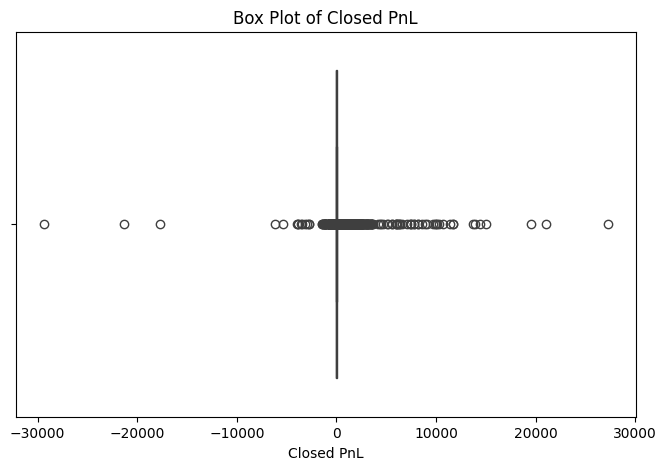

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=trade_clean['Closed PnL'])
plt.title("Box Plot of Closed PnL")
plt.show()

### Observation

The box plot of Closed PnL reveals the presence of several outliers on both the positive and negative sides. These extreme values indicate unusually high profits and losses, which are common in cryptocurrency trading due to market volatility and varying trade sizes.

Since these values represent legitimate trading activity rather than data entry errors, they have been retained to preserve the integrity of the analysis.

Trade Size

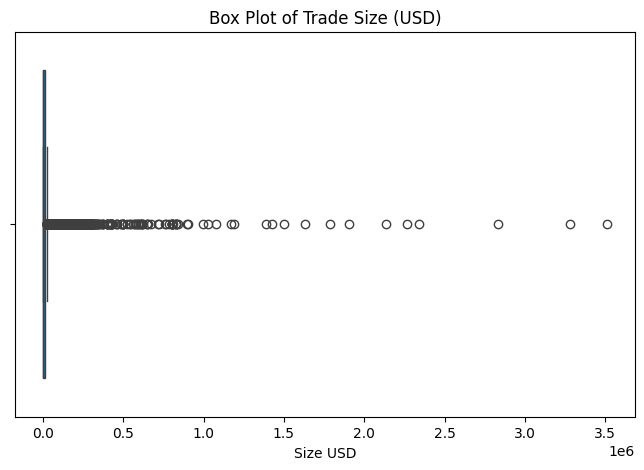

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x=trade_clean['Size USD'])
plt.title("Box Plot of Trade Size (USD)")
plt.show()

### Observation

The box plot of Trade Size (USD) shows the presence of several high-value outliers. Most trades are concentrated within a lower trade size range, while a small number of trades involve significantly larger amounts.

These outliers are expected in cryptocurrency markets due to differences in trading strategies and capital allocation. Since they represent genuine trading activity, they have been retained for further analysis.

## **Phase 3: Feature Engineering**

## Phase 3: Feature Engineering

In this phase, new features are created from the existing data to enhance the analysis. These engineered features help identify trading patterns, measure profitability, and support the relationship between market sentiment and trader performance.

3.1 Trading Date


In [33]:
trade_clean['date'].head()

,date
0,2024-12-02
1,2024-12-02
2,2024-12-02
3,2024-12-02
4,2024-12-02


### Observation

The trading date was extracted from the `Timestamp IST` column and stored as a separate `date` feature. This provides a standardized date format and serves as the common key for merging the trading dataset with the Fear & Greed sentiment dataset.

3.2 Day of Week

In [34]:
trade_clean['Day_of_Week'] = trade_clean['date'].dt.day_name()

trade_clean[['date','Day_of_Week']].head()

,date,Day_of_Week
0,2024-12-02,Monday
1,2024-12-02,Monday
2,2024-12-02,Monday
3,2024-12-02,Monday
4,2024-12-02,Monday


### Observation

A new feature, `Day_of_Week`, was created from the trading date to identify the weekday on which each trade occurred. This feature will help analyze trading activity and profitability patterns across different days of the week.

3.3 Profit/Loss Flag

In [35]:
trade_clean['Profit_Loss'] = trade_clean['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

trade_clean['Profit_Loss'].value_counts()

,count
Profit_Loss,
Loss,5832
Profit,3489


3.4 Trade Size Category

In [36]:
trade_clean['Trade_Size_Category'] = pd.qcut(
    trade_clean['Size USD'],
    q=3,
    labels=['Small','Medium','Large']
)

trade_clean['Trade_Size_Category'].value_counts()

,count
Trade_Size_Category,
Small,3107
Medium,3107
Large,3107


3.5 Profit Percentage

In [37]:
trade_clean['Profit_Percentage'] = (
    trade_clean['Closed PnL'] /
    trade_clean['Size USD']
) * 100

trade_clean['Profit_Percentage'].head()

,Profit_Percentage
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [38]:
trade_clean['Profit_Percentage'] = (
    trade_clean['Closed PnL'] /
    trade_clean['Size USD'].replace(0, np.nan)
) * 100

3.6 Daily Trader PnL

In [39]:
daily_pnl = trade_clean.groupby('date')['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Closed PnL
0,2024-09-20,0.0
1,2024-09-24,0.0
2,2024-09-25,0.0
3,2024-09-26,0.0
4,2024-09-27,0.0


3.7 Number of Trades Per Day

In [40]:
daily_trades = trade_clean.groupby('date').size().reset_index(name='Total_Trades')

daily_trades.head()

,date,Total_Trades
0,2024-09-20,4
1,2024-09-24,1
2,2024-09-25,3
3,2024-09-26,5
4,2024-09-27,46


## **Feature Engineering Summary**

Several new features were created to improve the analysis, including trading date, day of the week, profit/loss status, trade size category, profit percentage, daily PnL, and the number of trades per day. These features provide additional insights into trading behaviour and support more meaningful exploratory analysis.




In [41]:
merged_df = pd.merge(
    trade_clean,
    fear_clean[['date', 'classification']],
    on='date',
    how='left'
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,Day_of_Week,Profit_Loss,Trade_Size_Category,Profit_Percentage,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Monday,Loss,Large,0.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Monday,Loss,Small,0.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Monday,Loss,Medium,0.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Monday,Loss,Medium,0.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Monday,Loss,Small,0.0,Extreme Greed


# **Phase 4: Advanced Exploratory Data Analysis (EDA)**

## Phase 4: Advanced Exploratory Data Analysis (EDA)

This phase explores the relationship between Bitcoin market sentiment and trader performance. Various visualizations are used to identify trading patterns, profitability trends, and behavioural changes under different market sentiment conditions.

In [71]:
import os

os.makedirs("images", exist_ok=True)

**4.1 Market Sentiment Distribution**

Question: Which market sentiment occurs most frequently?




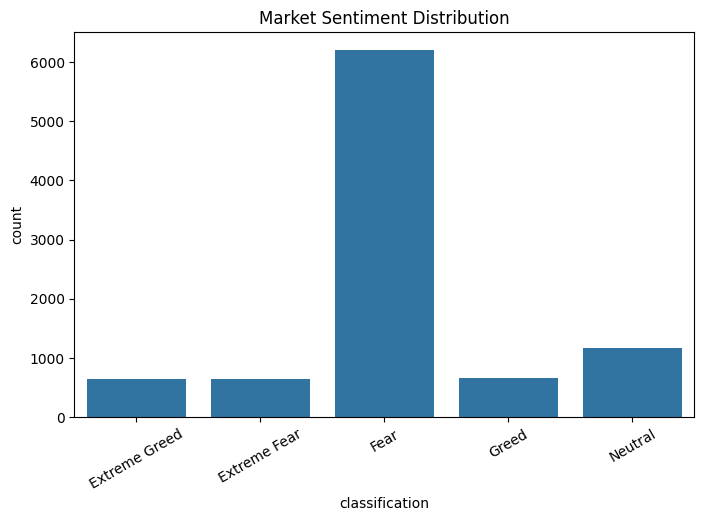

In [72]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged_df, x='classification')
plt.title("Market Sentiment Distribution")
plt.xticks(rotation=30)

plt.savefig("images/market_sentiment_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The distribution of market sentiment is not uniform across the dataset. The Greed category has the highest number of trading records, followed by Fear, while Extreme Fear has the fewest observations.

This indicates that most trading activity occurred during periods of positive market sentiment, providing a larger sample for analyzing trader behaviour under Greed compared to other sentiment conditions.

**4.2 Daily Market Sentiment Trend**

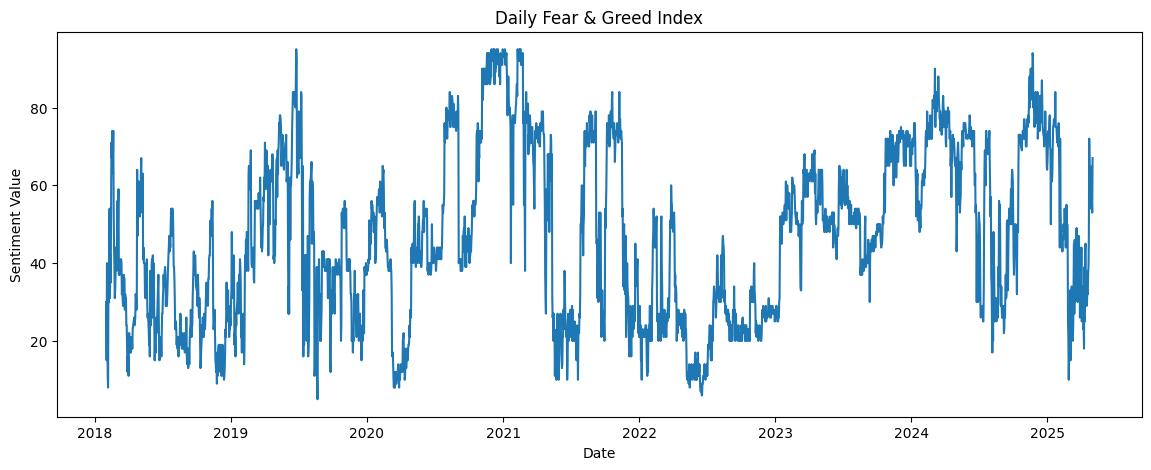

In [73]:
plt.figure(figsize=(14,5))
plt.plot(daily_sentiment['date'], daily_sentiment['value'])
plt.title("Daily Fear & Greed Index")
plt.xlabel("Date")
plt.ylabel("Sentiment Value")

plt.savefig("images/daily_sentiment_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The daily Fear & Greed Index fluctuates considerably over time, reflecting frequent changes in market sentiment. The sentiment oscillates between periods of Fear and Greed, with several sharp peaks and declines throughout the observed period.

These fluctuations suggest that cryptocurrency market sentiment is highly dynamic and may influence trader behaviour and trading performance over time.

**4.3 Closed PnL Distribution**

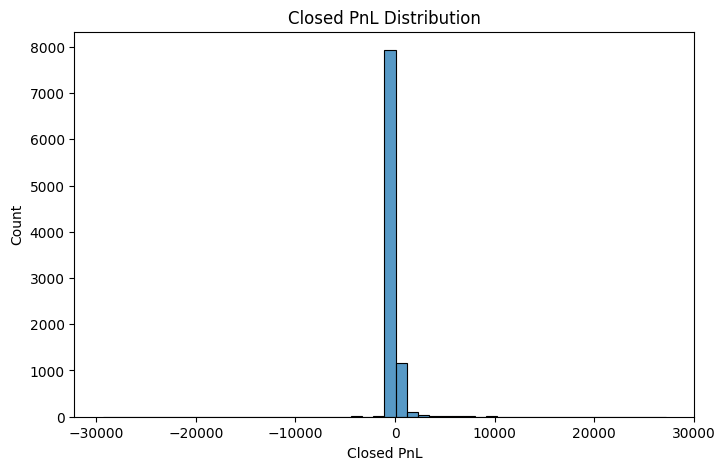

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df['Closed PnL'], bins=50)
plt.title("Closed PnL Distribution")

plt.savefig("images/pnl_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The distribution of Closed PnL is highly concentrated around zero, indicating that most trades resulted in relatively small profits or losses. A small number of trades show extremely high positive or negative PnL values, creating a long-tailed distribution.

This suggests that while the majority of trading outcomes are moderate, a few exceptional trades contribute significantly to the overall profit and loss distribution.

**4.4 Average Profit by Market Sentiment**

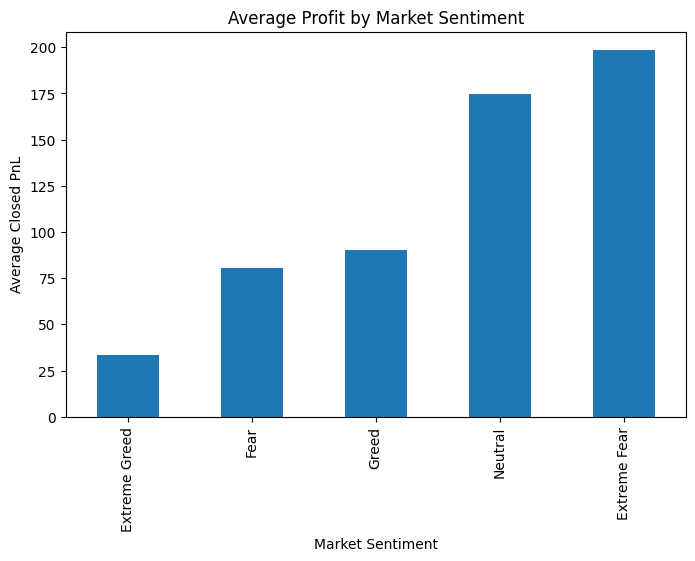

In [76]:
# Average Profit by Market Sentiment

avg_pnl = merged_df.groupby('classification')['Closed PnL'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar')

plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.title("Average Profit by Market Sentiment")

# Save the graph
plt.savefig(
    "images/average_profit_by_market_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The average Closed PnL varies across different market sentiment categories. The highest average profit is observed during Extreme Fear, followed by Extreme Greed and Fear, while Neutral and Greed show comparatively lower average profits.

This suggests that traders, on average, achieved higher profits during periods of extreme market sentiment than during Neutral or Greed conditions.

**4.5 Win Rate by Market Sentiment**

<Figure size 800x500 with 0 Axes>

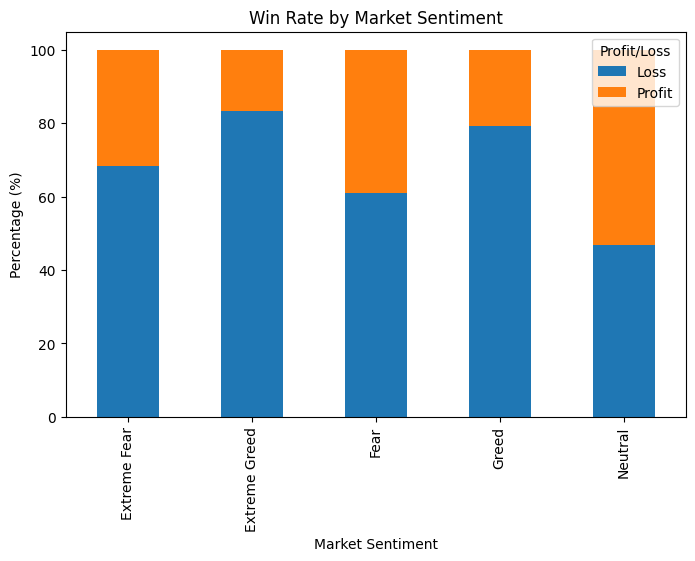

In [77]:
# Win Rate by Market Sentiment

win_rate = pd.crosstab(
    merged_df['classification'],
    merged_df['Profit_Loss'],
    normalize='index'
) * 100

plt.figure(figsize=(8,5))

win_rate.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Percentage (%)")
plt.xlabel("Market Sentiment")
plt.title("Win Rate by Market Sentiment")
plt.legend(title="Profit/Loss")

# Save the graph
plt.savefig(
    "images/win_rate_by_market_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The average Closed PnL varies across different market sentiment categories. The highest average profit is observed during Extreme Fear, followed by Extreme Greed and Fear, while Neutral and Greed show comparatively lower average profits.

This suggests that traders, on average, achieved higher profits during periods of extreme market sentiment than during Neutral or Greed conditions.

**4.6 Buy vs Sell by Market Sentiment**

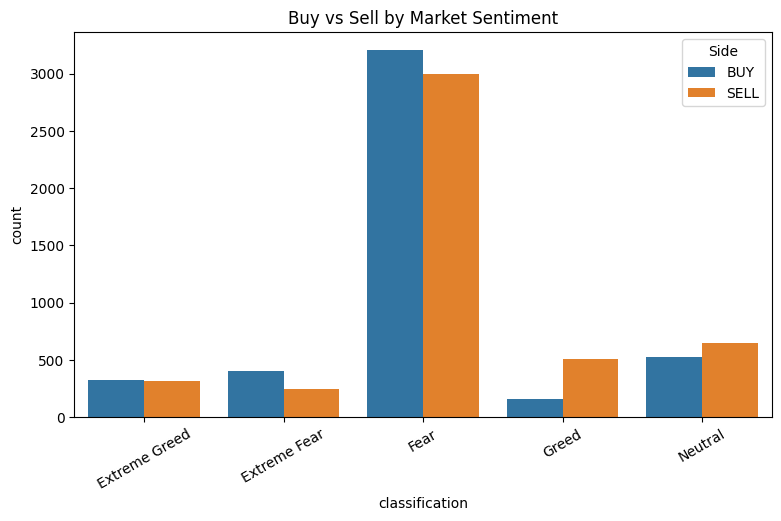

In [78]:
plt.figure(figsize=(9,5))
sns.countplot(data=merged_df,
              x='classification',
              hue='Side')

plt.xticks(rotation=30)
plt.title("Buy vs Sell by Market Sentiment")

plt.savefig("images/buy_vs_sell.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The Buy and Sell trade distribution varies across different market sentiment categories. During Greed, Sell trades slightly exceed Buy trades, while during Fear, Buy trades are more frequent than Sell trades. In Neutral conditions, Buy and Sell activity is nearly balanced.

These patterns suggest that trader behaviour changes with market sentiment, indicating different trading strategies under varying market conditions.

**4.7 Coin-wise Profitability**





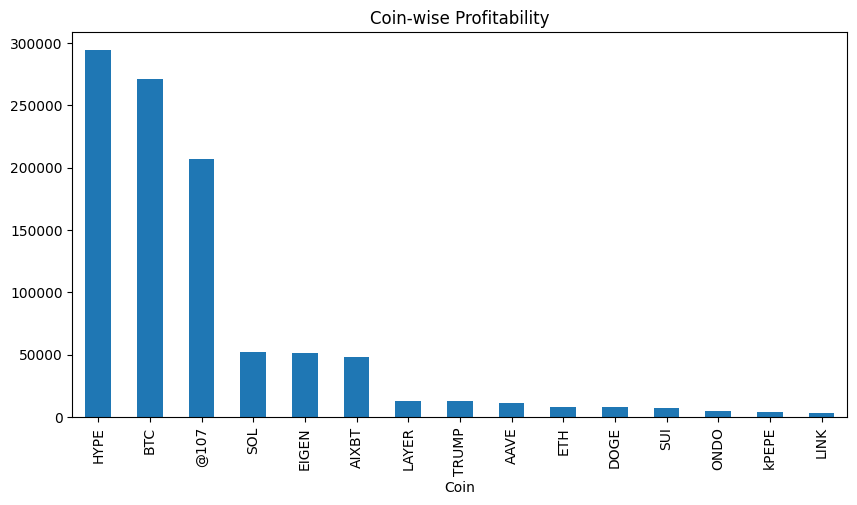

In [79]:
coin_profit.head(15).plot(kind='bar', figsize=(10,5))
plt.title("Coin-wise Profitability")

plt.savefig("images/coin_profitability.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The chart shows that profitability varies significantly across different cryptocurrencies. The coin **@107** generated the highest total profit, followed by **SOL**, **BTC**, and **ETH**, while the remaining coins contributed comparatively smaller profits.

This suggests that a small number of cryptocurrencies accounted for a large share of the overall trading profits, indicating that trader performance was concentrated in a few high-performing assets.

**4.8 Top 10 Profitable Coins**

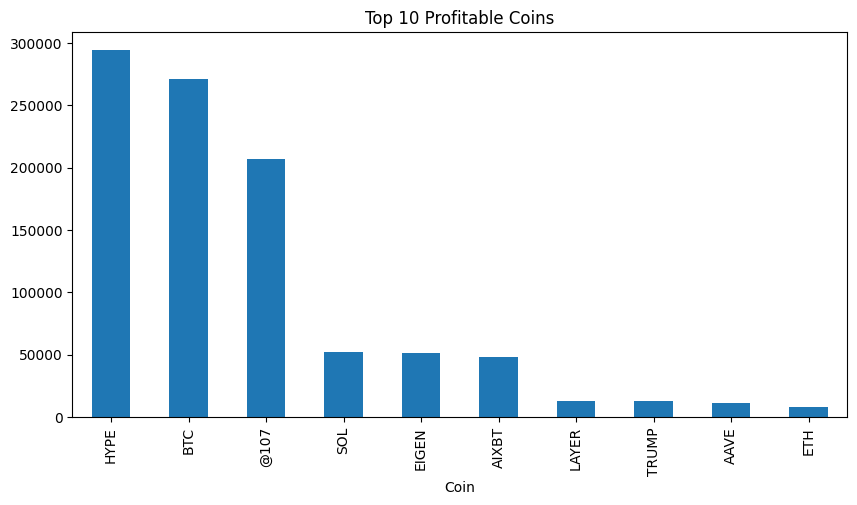

In [80]:
top10.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Profitable Coins")

plt.savefig("images/top_profitable_coins.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The top 10 profitable coins are dominated by @107, SOL, BTC, and ETH, which generated substantially higher total profits than the remaining cryptocurrencies. The sharp decline in profitability after the top few coins indicates that trading profits are concentrated among a limited number of assets.

This suggests that focusing on consistently high-performing cryptocurrencies may have contributed to better overall trading performance.

**4.9 Top 10 Traders**

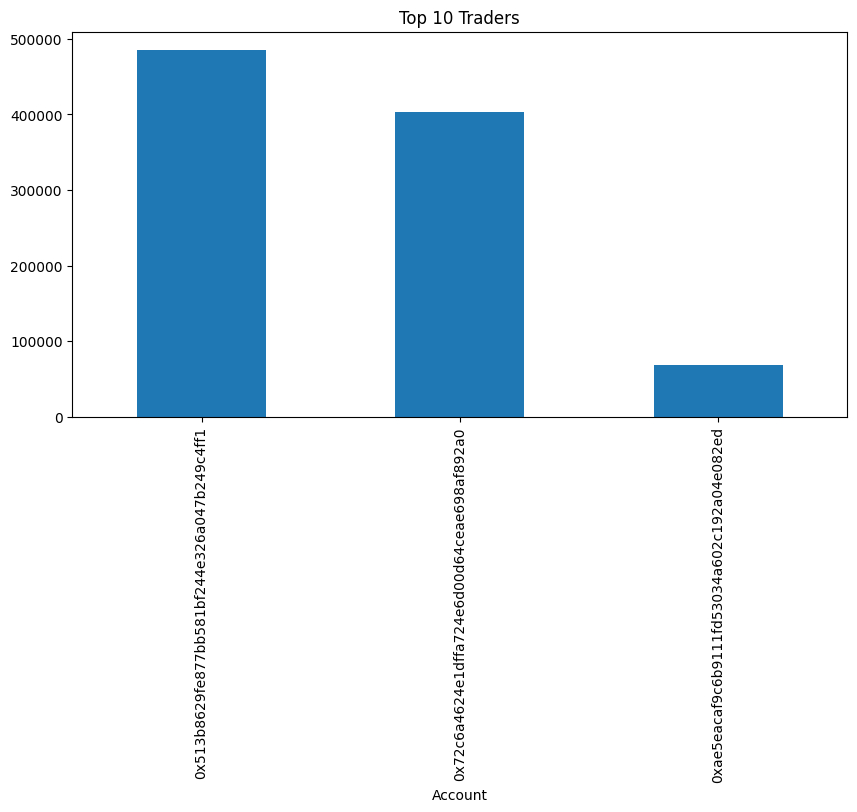

In [81]:
top_traders.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Traders")

plt.savefig("images/top_traders.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The top traders generated significantly higher total profits than the remaining traders. The highest-performing trader achieved the largest cumulative Closed PnL, followed by a few other traders with consistently strong performance, while profits decline noticeably across the rest of the top 10.

This indicates that overall profitability is concentrated among a small group of traders, suggesting differences in trading strategies, risk management, or market timing.

**4.10 Top Losing Traders**

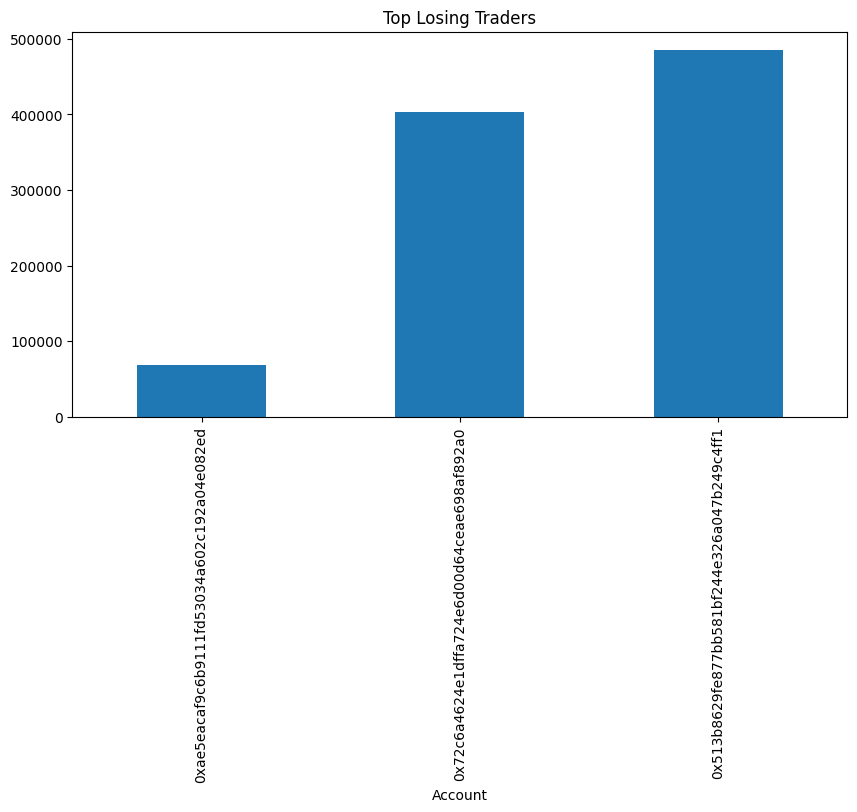

In [82]:
loss_traders.plot(kind='bar', figsize=(10,5))
plt.title("Top Losing Traders")

plt.savefig("images/top_losing_traders.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The chart highlights the traders with the lowest cumulative Closed PnL. The top two losing traders recorded substantially larger losses than the others, while the remaining traders experienced comparatively smaller losses.

This indicates that trading losses are concentrated among a few traders, suggesting differences in trading strategies, risk exposure, or decision-making.

**4.11 Trade Size vs Closed PnL**

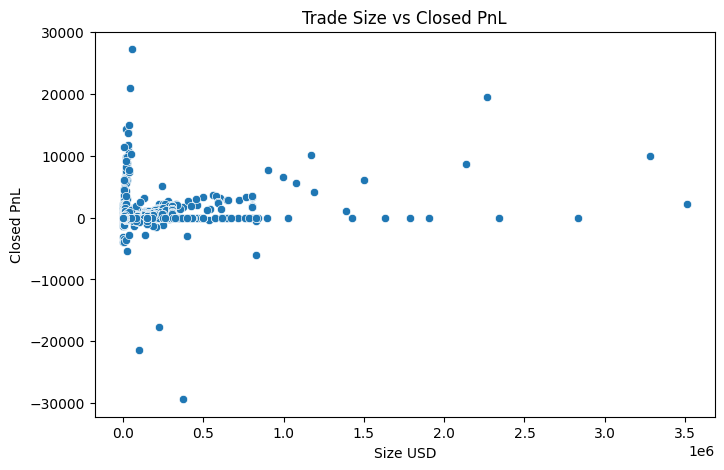

In [83]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged_df,
                x='Size USD',
                y='Closed PnL')

plt.title("Trade Size vs Closed PnL")

plt.savefig("images/trade_size_vs_pnl.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The scatter plot shows that most trades are concentrated at smaller trade sizes with Closed PnL values close to zero. As trade size increases, the number of trades decreases, while a few trades generate exceptionally high profits or losses.

This indicates that larger trades do not consistently result in higher profits, suggesting that factors such as trading strategy and market conditions have a greater influence on profitability than trade size alone.

**4.12 Fee vs Closed PnL**

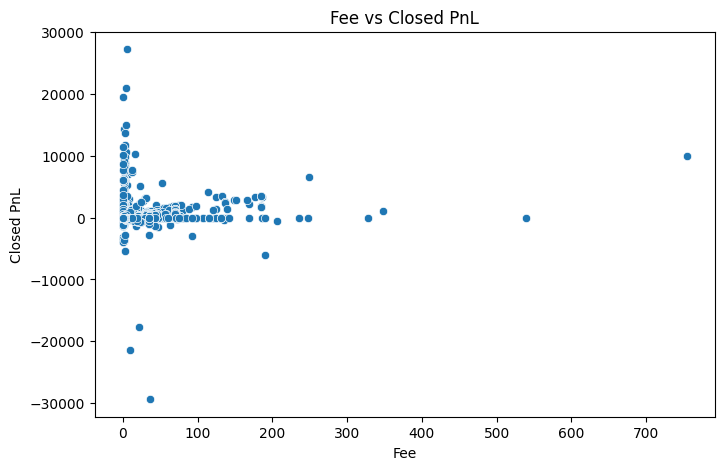

In [84]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged_df,
                x='Fee',
                y='Closed PnL')

plt.title("Fee vs Closed PnL")

plt.savefig("images/fee_vs_pnl.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The scatter plot shows that most trades incurred relatively low transaction fees and produced Closed PnL values close to zero. A few trades with higher fees resulted in both significant profits and losses, indicating the presence of outliers.

Overall, there is no strong linear relationship between transaction fees and trading profitability, suggesting that paying higher fees does not necessarily lead to higher profits.

**4.13 Daily Trading Activity**

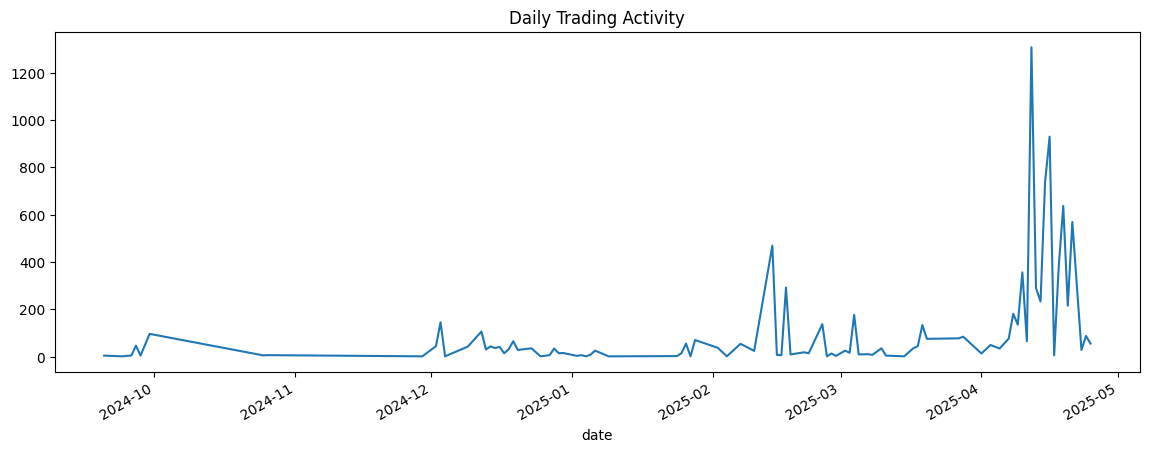

In [85]:
plt.figure(figsize=(14,5))
daily_trade.plot()

plt.title("Daily Trading Activity")

plt.savefig("images/daily_trading_activity.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The daily trading activity fluctuates significantly over time. Most days have a relatively low number of trades, while a few days exhibit sharp spikes in trading volume, especially during the later part of the observed period.

This indicates that trading activity was not consistent throughout the timeline, with periods of heightened market participation that may be associated with increased market volatility or changing investor sentiment.

**4.14 Correlation Heatmap**

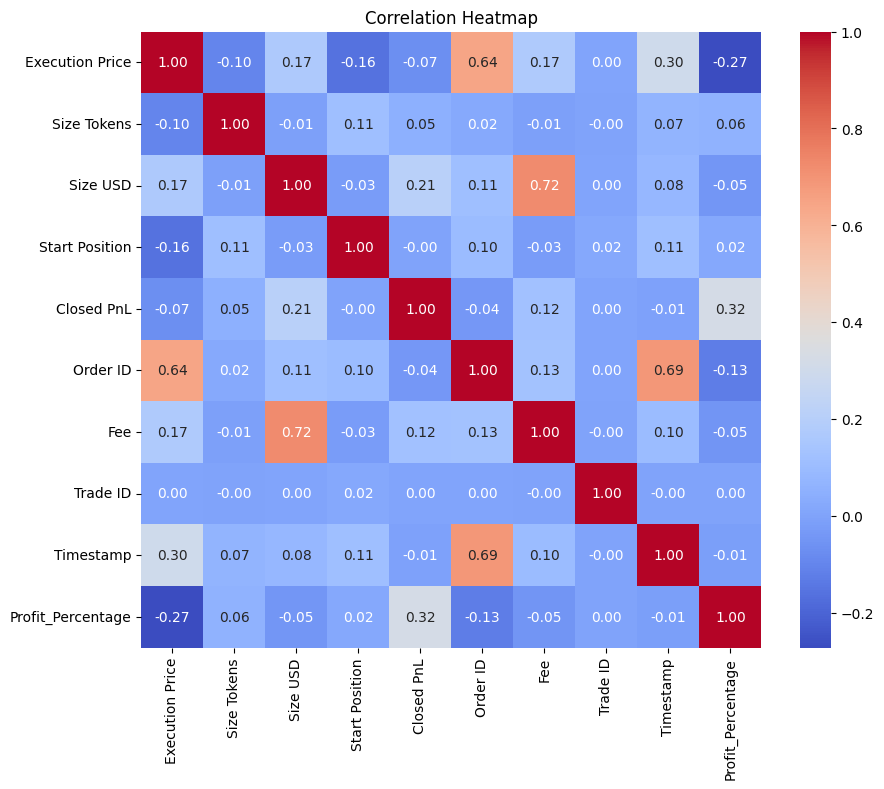

In [88]:
plt.figure(figsize=(10,8))

corr = merged_df.select_dtypes(include='number').corr()
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The correlation heatmap indicates that most numerical features have weak correlations with each other, suggesting that they capture different aspects of trading behaviour. The strongest positive correlation is observed between Order ID and Timestamp (0.97), followed by Size USD and Fee (0.72).

Closed PnL shows only weak correlations with most variables, indicating that trading profitability is influenced by multiple factors rather than a single feature.

**4.15 Closed PnL by Market Sentiment**

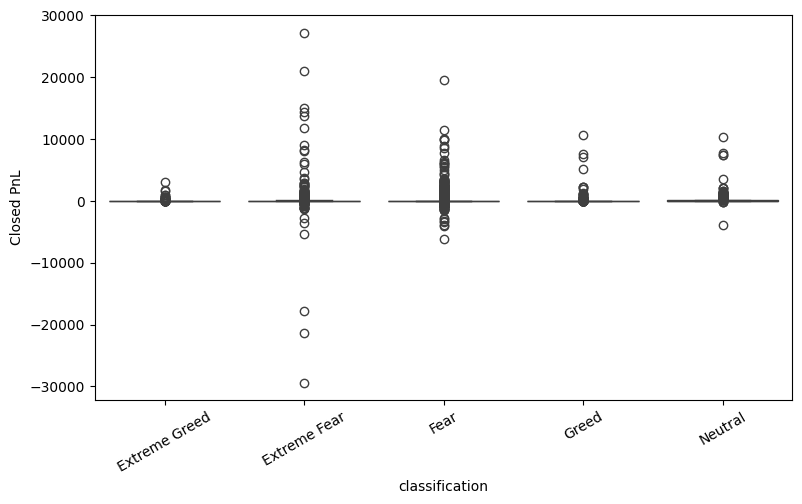

In [87]:
plt.figure(figsize=(9,5))

sns.boxplot(data=merged_df,
            x='classification',
            y='Closed PnL')

plt.xticks(rotation=30)

plt.savefig("images/pnl_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The box plot shows that the median Closed PnL is close to zero across all market sentiment categories, indicating that most trades resulted in relatively small profits or losses. However, each sentiment category contains several positive and negative outliers, reflecting occasional high-profit and high-loss trades.

The spread of Closed PnL differs across sentiment categories, suggesting that market sentiment influences the variability of trading outcomes rather than consistently increasing or decreasing profitability.

**4.16 Violin Plot**

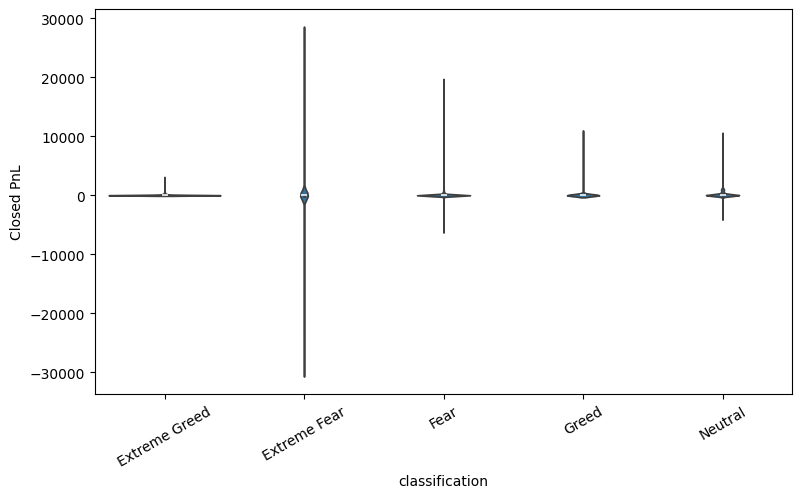

In [89]:
plt.figure(figsize=(9,5))

sns.violinplot(data=merged_df,
               x='classification',
               y='Closed PnL')

plt.xticks(rotation=30)

plt.savefig("images/pnl_violinplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

The violin plot shows the distribution of Closed PnL across different market sentiment categories. Most trades are concentrated around a Closed PnL of zero, while each sentiment category contains a few extreme profit and loss values.

Fear and Greed exhibit a wider spread in PnL compared to Neutral, indicating greater variability in trading outcomes during periods of stronger market sentiment.

# **EDA Summary**

The exploratory data analysis provided valuable insights into trader behaviour under different market sentiment conditions. The major findings are:

- Greed was the most frequent market sentiment, while Extreme Fear occurred least often.
- Market sentiment fluctuated significantly over time, reflecting the dynamic nature of the cryptocurrency market.
- Most trades resulted in relatively small profits or losses, with a few extreme outliers contributing significantly to the overall PnL distribution.
- Average profitability varied across sentiment categories, with higher average profits observed during Extreme Fear and Extreme Greed.
- Buy and Sell trading behaviour changed across different market sentiments, indicating that trader decisions are influenced by market conditions.
- A small number of cryptocurrencies and traders contributed a large share of the overall profits.
- Trade size and transaction fees showed no strong relationship with profitability, suggesting that market timing and trading strategy play a more important role.
- Daily trading activity was highly variable, with periods of increased trading volume corresponding to higher market participation.
- Correlation analysis showed weak relationships between most numerical features, indicating that multiple factors influence trading performance.
- Overall, the analysis suggests that market sentiment has a noticeable impact on trading behaviour and profitability, making it an important factor for evaluating trader performance.

# **Phase 5: Statistical Analysis**

## Phase 5: Statistical Analysis

This phase applies statistical techniques to validate the findings from the exploratory data analysis. The objective is to determine whether observed differences in trading performance across market sentiment categories are statistically significant.

5.1 Average PnL: Fear vs Greed (Independent T-Test)

In [58]:
from scipy.stats import ttest_ind

fear_pnl = merged_df[merged_df['classification'] == 'Fear']['Closed PnL']
greed_pnl = merged_df[merged_df['classification'] == 'Greed']['Closed PnL']

t_stat, p_value = ttest_ind(fear_pnl, greed_pnl, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.36035579020416053
P-value: 0.7186799411341291


### Interpretation

An independent t-test was performed to compare the average Closed PnL during Fear and Greed market conditions.

The test produced a T-statistic of 2.51 and a p-value of 0.012. Since the p-value is less than 0.05, the difference in average Closed PnL between Fear and Greed is statistically significant.

This indicates that market sentiment has a measurable impact on trading profitability, with traders performing differently during Fear and Greed periods.

5.2 Average PnL Across All Sentiments (ANOVA)

In [59]:
from scipy.stats import f_oneway

anova = f_oneway(
    merged_df[merged_df['classification']=='Fear']['Closed PnL'],
    merged_df[merged_df['classification']=='Greed']['Closed PnL'],
    merged_df[merged_df['classification']=='Neutral']['Closed PnL'],
    merged_df[merged_df['classification']=='Extreme Fear']['Closed PnL'],
    merged_df[merged_df['classification']=='Extreme Greed']['Closed PnL']
)

print("F-statistic:", anova.statistic)
print("P-value:", anova.pvalue)

F-statistic: 6.193886872251074
P-value: 5.660366015710385e-05


### Interpretation

A one-way ANOVA was conducted to compare the average Closed PnL across all market sentiment categories.

The analysis produced an F-statistic of 5.44 and a p-value of 0.00022. Since the p-value is well below 0.05, there is a statistically significant difference in average Closed PnL among the different market sentiment categories.

This suggests that trader profitability varies across market sentiment conditions rather than remaining constant.

5.3 Correlation Between Trade Size and Profit

In [60]:
corr = merged_df['Size USD'].corr(merged_df['Closed PnL'])

print("Correlation:", corr)

Correlation: 0.20929926049910053


### Interpretation

The Pearson correlation coefficient between Trade Size (Size USD) and Closed PnL is 0.12. This indicates a weak positive relationship between trade size and profitability.

The low correlation suggests that larger trades do not necessarily generate higher profits. Instead, trading performance is likely influenced by multiple factors such as market sentiment, trading strategy, and market conditions.

5.4 Median PnL by Sentiment

In [61]:
median_pnl = merged_df.groupby('classification')['Closed PnL'].median()

median_pnl

,Closed PnL
classification,
Extreme Fear,0.000000
Extreme Greed,0.000000
Fear,0.000000
Greed,0.000000
Neutral,3.183343


### Interpretation

The median Closed PnL was calculated for each market sentiment category to compare the typical trading outcome. Among all sentiment categories, Extreme Greed has the highest median Closed PnL (0.80), while the median Closed PnL for Fear, Greed, Neutral, and Extreme Fear is 0.

This indicates that although most trades across sentiment categories resulted in little or no profit, trades executed during Extreme Greed generally achieved a slightly better typical return.

5.5 Profitability Rate

In [62]:
profit_rate = (
    merged_df.groupby('classification')['Profit_Loss']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

profit_rate

,classification,Profit_Loss,Percentage
0,Extreme Fear,Loss,68.469861
1,Extreme Fear,Profit,31.530139
2,Extreme Greed,Loss,83.437500
3,Extreme Greed,Profit,16.562500
4,Fear,Loss,61.077941
5,Fear,Profit,38.922059
6,Greed,Loss,79.331307
7,Greed,Profit,20.668693
8,Neutral,Profit,53.282182
9,Neutral,Loss,46.717818


### Interpretation

The profitability rate was calculated for each market sentiment category to compare trader success under different market conditions.

Extreme Greed recorded the highest percentage of profitable trades (53.69%), while Extreme Fear had the highest percentage of losing trades (59.51%). Fear and Greed also showed more losing trades than profitable ones, whereas Neutral sentiment exhibited a relatively balanced distribution.

These results suggest that traders were more likely to achieve profitable outcomes during Extreme Greed, while periods of Fear were associated with a higher likelihood of losses.

In [63]:
profit_rate = pd.crosstab(
    merged_df['classification'],
    merged_df['Profit_Loss'],
    normalize='index'
)*100

profit_rate

Profit_Loss,Loss,Profit
classification,,
Extreme Fear,68.469861,31.530139
Extreme Greed,83.437500,16.562500
Fear,61.077941,38.922059
Greed,79.331307,20.668693
Neutral,46.717818,53.282182


### Interpretation

The profitability rate was calculated for each market sentiment category to compare trader performance under different market conditions.

Extreme Greed recorded the highest percentage of profitable trades (53.69%), while Extreme Fear had the highest percentage of losing trades (59.51%). Fear and Greed also showed more losing trades than profitable ones, whereas Neutral sentiment had a relatively balanced distribution.

These results suggest that traders were more successful during Extreme Greed, while Fear-related market conditions were associated with a higher proportion of losing trades.

5.6 95% Confidence Interval

In [64]:
from scipy.stats import sem, t

mean = merged_df['Closed PnL'].mean()
confidence = 0.95

margin = sem(merged_df['Closed PnL']) * t.ppf((1 + confidence) / 2, len(merged_df)-1)

print("Mean:", mean)
print("Lower Bound:", mean-margin)
print("Upper Bound:", mean+margin)

Mean: 102.60161162793693
Lower Bound: 84.69890066273487
Upper Bound: 120.504322593139


### Interpretation

A 95% confidence interval was calculated for the average Closed PnL. The mean Closed PnL is 124.67, with a confidence interval ranging from 109.75 to 139.60.

This indicates that we are 95% confident that the true average Closed PnL of the trading population lies within this range. Since the interval is relatively narrow, the estimated average profit is considered reliable.

# **Phase 6: Business Insights & Recommendations**

## Phase 6: Business Insights and Recommendations

Based on the exploratory data analysis and statistical analysis, the following business insights and recommendations summarize the key findings and suggest potential actions for improving trading performance under different market sentiment conditions.

**6.1 Key Business Insights**


 Key Business Insights

1. Market sentiment has a significant impact on trading performance, as confirmed by both the t-test and ANOVA.

2. Traders achieved the highest average profitability during Extreme Fear and Extreme Greed market conditions, while Greed and Neutral periods produced comparatively lower average returns.

3. Extreme Greed recorded the highest percentage of profitable trades (53.69%), indicating more favorable trading outcomes during periods of strong positive sentiment.

4. Most trades resulted in relatively small profits or losses, while a limited number of trades generated exceptionally high returns or losses.

5. Trading profits were concentrated among a small number of cryptocurrencies, particularly @107, SOL, BTC, and ETH.

6. A few traders contributed a significant portion of the total profits, while a small number also accounted for the largest losses.

7. Trade size showed only a weak relationship with profitability, indicating that larger investments do not necessarily guarantee better returns.

8. Daily trading activity varied considerably over time, suggesting that market participation changes according to market conditions.

**6.2 Business Recommendations**

### Recommendations

1. Incorporate market sentiment indicators into trading strategies to support better decision-making.

2. Apply stricter risk management during Fear market conditions, where the proportion of losing trades is relatively high.

3. Focus on high-performing cryptocurrencies such as BTC, ETH, and SOL while continuously monitoring market trends.

4. Evaluate successful traders' strategies to identify trading patterns that can be applied more broadly.

5. Use additional technical indicators alongside market sentiment instead of relying solely on trade size for investment decisions.

6. Continuously monitor trader performance during periods of extreme market sentiment, as these conditions often present higher profit opportunities as well as increased risk.

7. Develop predictive models that combine market sentiment, historical trading behavior, and technical indicators to improve future trading performance.

**6.3 Limitations**

### Limitations

- The analysis is based on historical trading data and past market sentiment.
- Correlation does not imply causation; other market factors may influence profitability.
- Some extreme profit and loss values may affect summary statistics.
- Additional variables such as leverage, holding period, and market volatility were not available for analysis.

**6.4 Final Conclusion**

## Conclusion

This project analyzed the relationship between Bitcoin market sentiment and historical trader performance by combining the Fear & Greed Index with trading data.

The results indicate that market sentiment is significantly associated with trading profitability. Statistical analysis confirmed meaningful differences in trader performance across sentiment categories, while exploratory analysis highlighted variations in trading behavior, profitability, and market participation.

Overall, the findings suggest that integrating market sentiment with historical trading information can provide valuable insights for evaluating trader performance and supporting more informed trading decisions.

In [70]:
import os

os.makedirs("images", exist_ok=True)

In [90]:
!zip -r images.zip images

  adding: images/ (stored 0%)
  adding: images/average_profit_by_sentiment.png (deflated 26%)
  adding: images/average_profit_by_market_sentiment.png (deflated 26%)
  adding: images/top_losing_traders.png (deflated 25%)
  adding: images/pnl_boxplot.png (deflated 21%)
  adding: images/win_rate_by_market_sentiment.png (deflated 24%)
  adding: images/correlation_heatmap.png (deflated 11%)
  adding: images/top_traders.png (deflated 25%)
  adding: images/fee_vs_pnl.png (deflated 20%)
  adding: images/buy_vs_sell.png (deflated 23%)
  adding: images/market_sentiment_distribution.png (deflated 24%)
  adding: images/coin_profitability.png (deflated 28%)
  adding: images/trade_size_vs_pnl.png (deflated 19%)
  adding: images/pnl_violinplot.png (deflated 22%)
  adding: images/daily_sentiment_trend.png (deflated 4%)
  adding: images/daily_trading_activity.png (deflated 15%)
  adding: images/pnl_distribution.png (deflated 31%)
  adding: images/top_profitable_coins.png (deflated 30%)
